In [36]:
# importing the stuff i need
# pandas = for reading the csv and tables
# matplotlib = for making charts
# SentimentIntensityAnalyzer = a tool that guesses if text is happy or angry

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [37]:

df = pd.read_csv('googlereview_nitdelhi.csv')

df = df[['text', 'stars', 'likesCount', 'isLocalGuide']]

df.head()

,text,stars,likesCount,isLocalGuide
0,Nic nit ❤️,5,0,True
1,Good place,3,0,True
2,NaN,5,0,False
3,Wonderful facilities and affordable price,5,0,False
4,NaN,5,0,True


In [38]:
#cleanig ds
df = df.dropna(subset=['text'])
df = df.drop_duplicates(subset=['text'])

df.shape

(83, 4)

In [39]:
#starts count
df['stars'].value_counts()

stars
5    49
4    20
1     9
3     5
Name: count, dtype: int64

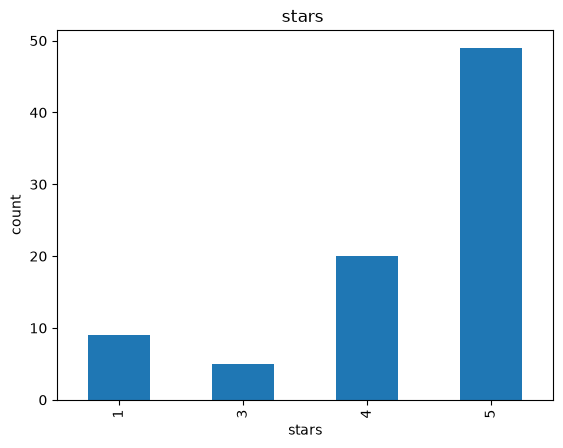

In [40]:
#data vizualisation
df['stars'].value_counts().sort_index().plot(kind='bar')

plt.title("stars ")
plt.xlabel("stars")
plt.ylabel("count")
plt.show()



In [41]:
#sentiment analysis
analyzer = SentimentIntensityAnalyzer()
analyzer.polarity_scores("this hostel is amazing i love it")

{'neg': 0.0, 'neu': 0.385, 'pos': 0.615, 'compound': 0.8402}

In [47]:
def get_score(text):
    result = analyzer.polarity_scores(text)
    return result['compound']  #compound = the overall score

df['sentiment_score'] = df['text'].apply(get_score)
df[['text', 'sentiment_score']].head(10)

,text,sentiment_score
0,Nic nit ❤️,0.0000
1,Good place,0.4404
3,Wonderful facilities and affordable price,0.5719
5,I am also in this good place to grow,0.5228
8,Good campus and infrastructure,0.4404
9,One to the modern premire instutite of India,0.0000
12,Institute is superb with great faculty and staff,0.8481
18,Gtbit is better,0.4404
20,One of the Best Engineering in India,0.6369
25,Awesome invironmet in campus,0.6249


In [48]:
#turing score into +ve _ve and deutral
def label_it(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df['feeling'] = df['sentiment_score'].apply(label_it)


df['feeling'].value_counts()

feeling
Positive    60
Neutral     17
Negative     6
Name: count, dtype: int64

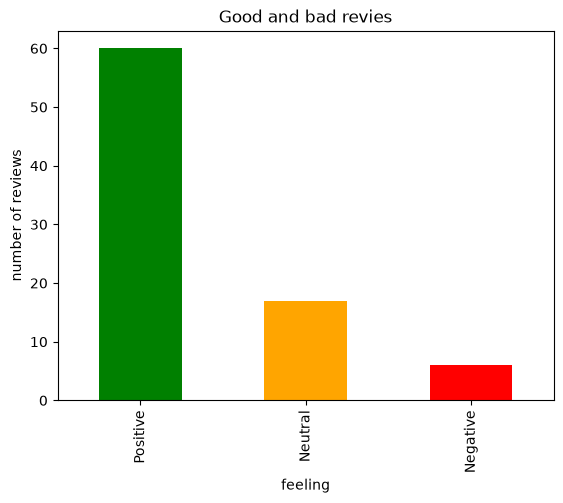

In [53]:
# bar chart 
df['feeling'].value_counts().plot(kind='bar', color=['green', 'orange', 'red'])

plt.title("Good and bad revies")
plt.xlabel("feeling")
plt.ylabel("number of reviews")
plt.show()

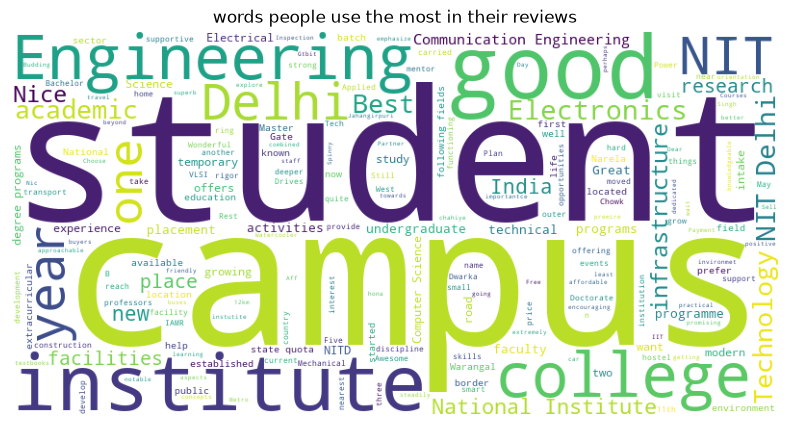

In [51]:
#word cloud
all_the_words = " ".join(df['text'])

cloud = WordCloud(width=800, height=400, background_color="white").generate(all_the_words)

plt.figure(figsize=(10,5))
plt.imshow(cloud)
plt.axis("off")  # dont need the x/y numbers for a picture
plt.title("words people use the most in their reviews")
plt.show()

In [49]:
#top revies

top_reviews = df.sort_values('likesCount', ascending=False)
top_reviews[['text', 'stars', 'feeling', 'likesCount']].head(5)

,text,stars,feeling,likesCount
88,One of the best NIT college and still underat...,5,Positive,9
217,"Nice college, I am doing B.Tech from here.",5,Positive,6
124,I am a Btech ECE'26 batch student.\nEnjoying c...,5,Positive,5
127,Not Good College.. Politics and baised for Wes...,1,Negative,4
287,"National Institute of Technology Delhi, abbrev...",3,Positive,4
